<div style="background-color: #d1ecf1; color: #0c5460; padding: 10px; border-radius: 5px; font-weight: bold; font-size: 18px;"><h3><align = "center">
  TASK 07 : Explainable AI Analysis
</div></h3>

# 1. Install and Import Libraries

In [1]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

shap.initjs()

# 2. Load Best Model and Data

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
from pathlib import Path

SAVE_DIR = Path("/content/drive/MyDrive/AI_Coursework/models")

split_data = joblib.load(SAVE_DIR / 'train_test_split.joblib')
X_train = split_data['X_train']
X_test = split_data['X_test']
y_test = split_data['y_test']

best_model_name = 'Logistic Regression'
best_model = joblib.load(SAVE_DIR / 'logistic_regression.joblib')

print(f"Explaining model: {best_model_name}")
print("X_test shape:", X_test.shape)

Explaining model: Logistic Regression
X_test shape: (200, 18)


# 3. Create the SHAP Explainer

In [4]:
explainer = shap.Explainer(lambda X: best_model.predict_proba(X)[:, 1], X_train)
shap_values = explainer(X_test)

print("SHAP values shape:", shap_values.values.shape)

PermutationExplainer explainer: 201it [00:10,  3.00it/s]                         

SHAP values shape: (200, 18)


# 4. Global Feature Importance (Summary Plot)

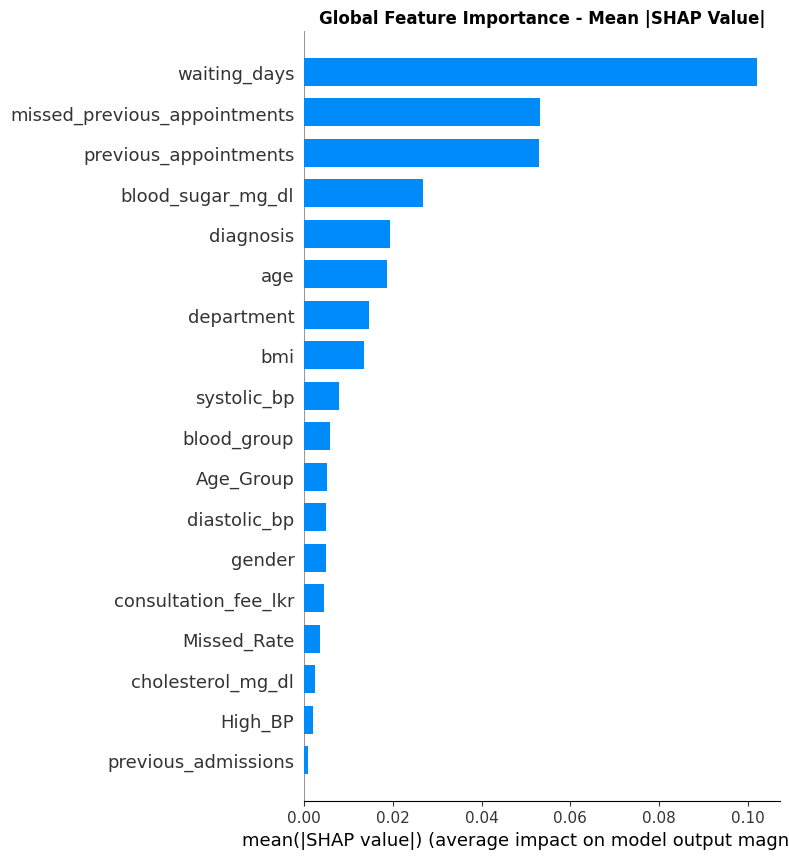

In [5]:
plt.figure()
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("Global Feature Importance - Mean |SHAP Value|", fontweight="bold")
plt.tight_layout()
plt.savefig("shap_bar_summary.png", dpi=150, bbox_inches="tight")
plt.show()

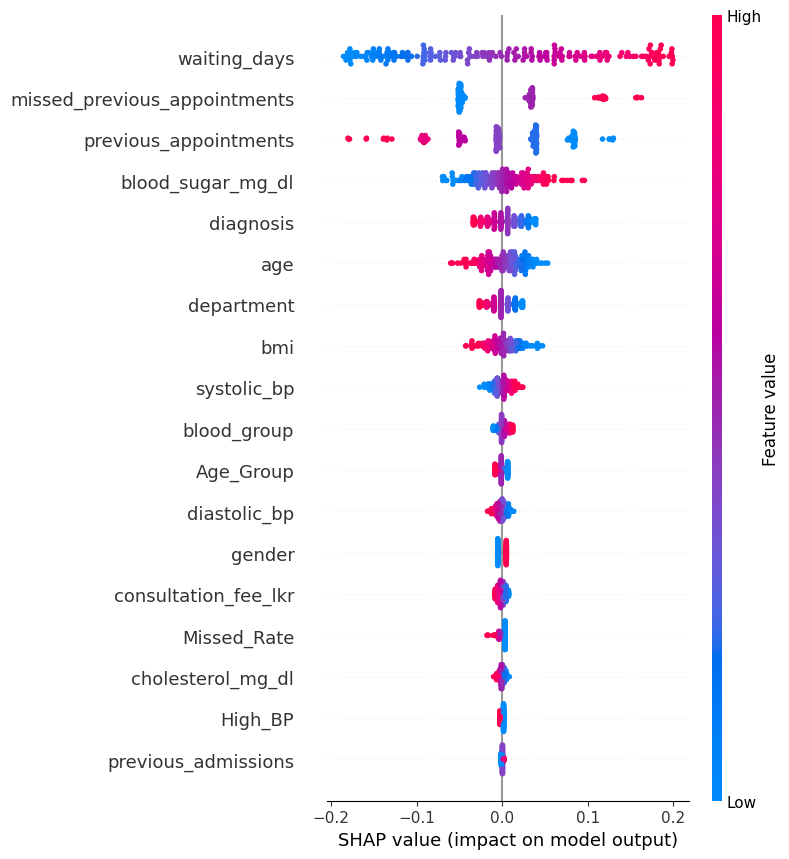

In [6]:
#Beeswarm Plot
plt.figure()
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.savefig("shap_beeswarm_summary.png", dpi=150, bbox_inches="tight")
plt.show()

# 5. Local Explanation - Individual Prediction

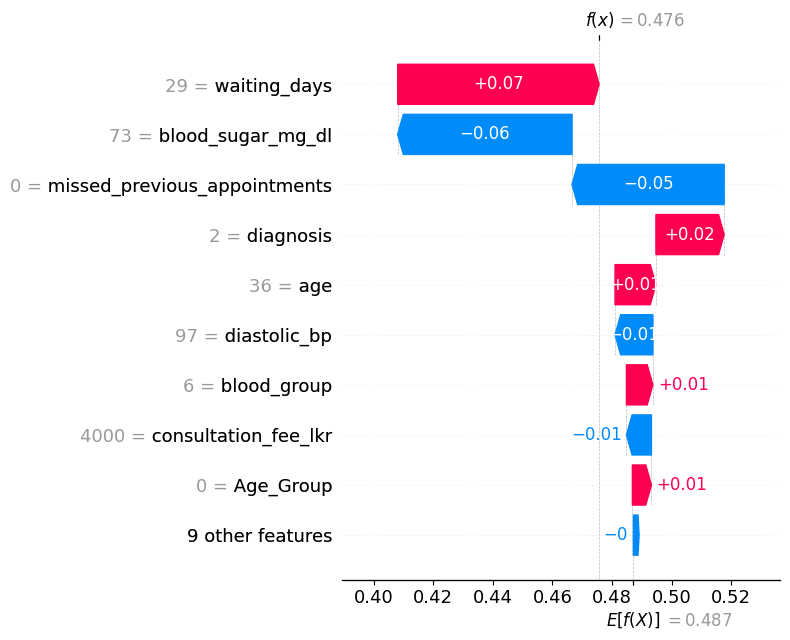

Actual label for this patient: No-Show
Predicted label: Attended


In [7]:
sample_idx = 0

plt.figure()
shap.plots.waterfall(shap_values[sample_idx], show=False)
plt.tight_layout()
plt.savefig("shap_waterfall_sample.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Actual label for this patient: {'No-Show' if y_test.iloc[sample_idx]==1 else 'Attended'}")
print(f"Predicted label: {'No-Show' if best_model.predict(X_test.iloc[[sample_idx]])[0]==1 else 'Attended'}")

# 6. Cross-Check with Model Coefficient

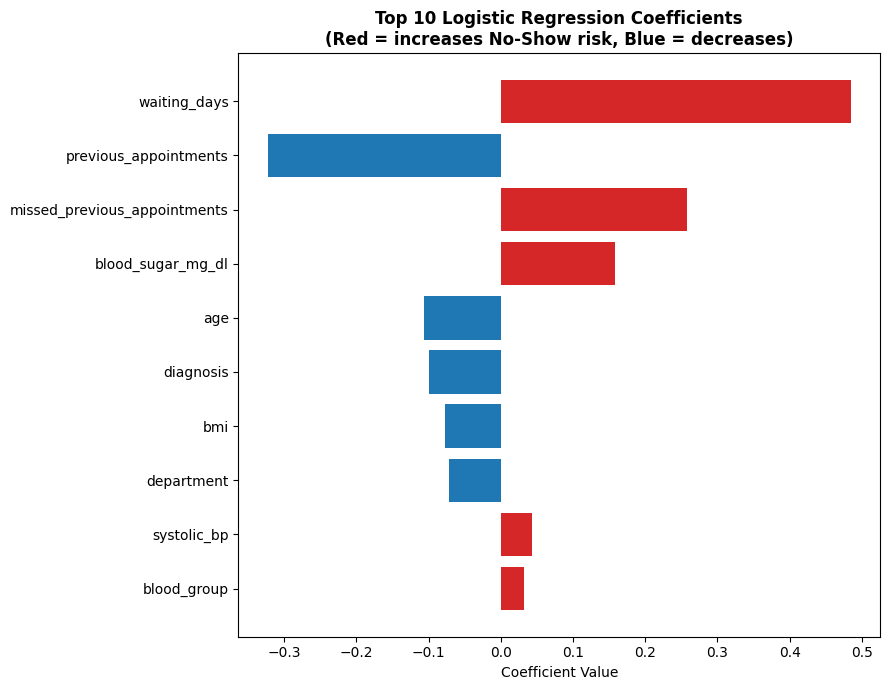

,Feature,Coefficient
0,waiting_days,0.484861
1,previous_appointments,-0.322975
2,missed_previous_appointments,0.258470
3,blood_sugar_mg_dl,0.158247
4,age,-0.106519
5,diagnosis,-0.099565
6,bmi,-0.077505
7,department,-0.071688
8,systolic_bp,0.043223
9,blood_group,0.031459


In [8]:
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": best_model.steps[-1][1].coef_[0]
}).sort_values("Coefficient", key=abs, ascending=False).reset_index(drop=True)

plt.figure(figsize=(9, 7))
colors = ["#d62728" if c > 0 else "#1f77b4" for c in coef_df["Coefficient"][:10]]
plt.barh(coef_df["Feature"][:10][::-1], coef_df["Coefficient"][:10][::-1], color=colors[::-1])
plt.title("Top 10 Logistic Regression Coefficients\n(Red = increases No-Show risk, Blue = decreases)", fontweight="bold")
plt.xlabel("Coefficient Value")
plt.tight_layout()
plt.savefig("lr_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()

coef_df.head(10)

# 7. SHAP-Based Interpretation


In [9]:
global_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'Mean_Abs_SHAP': np.abs(shap_values.values).mean(axis=0)
}).sort_values('Mean_Abs_SHAP', ascending=False).reset_index(drop=True)

display(global_importance.head(15))
global_importance.to_csv(SAVE_DIR / 'shap_global_importance.csv', index=False)

,Feature,Mean_Abs_SHAP
0,waiting_days,0.102140
1,missed_previous_appointments,0.053113
2,previous_appointments,0.053001
3,blood_sugar_mg_dl,0.026780
4,diagnosis,0.019390
5,age,0.018731
6,department,0.014515
7,bmi,0.013509
8,systolic_bp,0.007956
9,blood_group,0.005896


# 8. Save Explainability Outputs



In [10]:
coef_df.to_csv(SAVE_DIR / 'logistic_regression_coefficients.csv', index=False)
print(f'Saved: {SAVE_DIR / "logistic_regression_coefficients.csv"}')

Saved: /content/drive/MyDrive/AI_Coursework/models/logistic_regression_coefficients.csv


## 9. Local Prediction Reasoning



In [11]:
sample_idx = 0
prediction = best_model.predict(X_test.iloc[[sample_idx]])[0]
probability = best_model.predict_proba(X_test.iloc[[sample_idx]])[0, 1]

local_explanation = pd.DataFrame({
    'Feature': X_test.columns,
    'Feature_Value': X_test.iloc[sample_idx].values,
    'SHAP_Value': shap_values.values[sample_idx]
}).sort_values('SHAP_Value', key=abs, ascending=False)

display(local_explanation.head(10))
print('Actual label:', 'No-Show' if y_test.iloc[sample_idx] == 1 else 'Attended')
print('Predicted label:', 'No-Show' if prediction == 1 else 'Attended')
print(f'Predicted No-Show probability: {probability:.4f}')
local_explanation.to_csv(SAVE_DIR / 'shap_local_sample_0.csv', index=False)

,Feature,Feature_Value,SHAP_Value
5,waiting_days,29.0,0.067578
11,blood_sugar_mg_dl,73.0,-0.058486
7,missed_previous_appointments,0.0,-0.051033
4,diagnosis,2.0,0.022892
0,age,36.0,0.013717
10,diastolic_bp,97.0,-0.012693
2,blood_group,6.0,0.008871
14,consultation_fee_lkr,4000.0,-0.008388
15,Age_Group,0.0,0.006392
6,previous_appointments,3.0,-0.005595


Actual label: No-Show
Predicted label: Attended
Predicted No-Show probability: 0.4757


## 10. Interpretation, Transparency and Ethical Implications

### Important Features
The global SHAP analysis shows that **`waiting_days`** is the most influential feature for the Logistic Regression model. It is followed by **`missed_previous_appointments`**, **`previous_appointments`**, and **`admitted`**. Financial and laboratory variables such as **`lab_charge_lkr`**, **`total_bill_lkr`**, and **`lab_tests_count`** also contribute to predictions.

### Prediction Reasoning
SHAP values explain the direction and magnitude of individual feature contributions. A positive SHAP value moves the prediction toward the No-Show class, while a negative SHAP value moves it away from that class. For the example patient, the model predicted No-Show with a No-Show probability of approximately 0.5034 (which is > 0.5). The local explanation shows that waiting_days, treatments_count, and diagnosis pushed the prediction toward No-Show, while blood_sugar_mg_dl, missed_previous_appointments, and diastolic_bp pushed it in the opposite direction (toward Attended). The actual label for this example was No-Show, showing that the model correctly predicted this case.

### Transparency
Logistic Regression is relatively interpretable because its coefficients provide a direct indication of the direction of association between the encoded/scaled features and the model output. SHAP provides an additional patient-level explanation. Agreement between coefficient-based interpretation and SHAP-based importance provides a useful cross-check, although SHAP explanations describe the model's behavior rather than proving causal relationships.

### Ethical Implications
The prediction should be used as a **decision-support signal**, not as a reason to deny or restrict healthcare. Predictions can support appointment reminders, confirmation messages, and flexible rescheduling. Fairness should be monitored because demographic and other patient variables may contribute to predictions indirectly. Model performance is moderate (the selected Logistic Regression model achieved about **63% accuracy** on the evaluation set), so human oversight is necessary. Patient information and explanations should also be handled securely and only for legitimate healthcare purposes.
